# install package

In [1]:
pip install torch transformers huggingface_hub matplotlib seaborn numpy ipywidgets accelerate


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Import library

In [2]:
import repetition_neurons
import induction_heads
import utils
import induction_heads
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import random
from huggingface_hub import login
import json
from tqdm.notebook import tqdm
import os

global_seed = 42
repetition_neurons.seed_everything(global_seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = 'meta-llama/Llama-3.1-8B'

BASE_DIR = os.getcwd()
filename = f"repetition_neuron_data/{model_name[-10:]}.jsonl"
repetition_dataset = utils.load_data(filename)[:1000]

model, tokenizer = utils.load_model(model_name = model_name, seed=global_seed)

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:820: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

# Repetition neurons layer-wise experiment

In [4]:
def layer_wise(model, tokenizer, shot=10, K_values=[20, 50, 100, 180, 250], seed=42):
    sortedNeurons = repetition_neurons.find_sorted_neurons(model, tokenizer, base_data=repetition_dataset, seed=seed)
    tasks = ['rep', 'rec', 'ceb', 'wsq1','wsq2']
    d = {}
    for task in tqdm(tasks):
        file_data = f"./icl_data/{task}_{shot}shot.jsonl"
        ab_dataset = utils.load_data(file_data)
        ground_truths = [item['ground_truth'] for item in ab_dataset]
        nor_answer = utils.generate_answer(model, tokenizer, ab_dataset, seed)
        ab_nr_layer_result = repetition_neurons.run_segment_ablation_study_2phase(model, tokenizer, 
                                                                                  ab_dataset, sortedNeurons, 
                                                                                  neurons_to_ablate_list=K_values,seed=seed)
        nor_ =  utils.extract_answers_nor(nor_answer, shots = shot)
        nr_layer = utils.extract_answers_ab_layer(ab_nr_layer_result, shots=shot)
        d[task] = {
            'ground_truths': ground_truths,
            'nr_layer':      nr_layer,
            'nor_':          nor_,
        }
    return d

d = layer_wise(model, tokenizer, shot=10, K_values=[20, 50, 100, 180, 250, 350,500],seed=global_seed)

Sorted Repetition Neurons


Compute activation: 100%|██████████| 25/25 [00:15<00:00,  1.59sequence/s]


  0%|          | 0/5 [00:00<?, ?it/s]

Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`. This was detected when initializing the generation config instance, which means the corresponding file may hold incorrect parameterization and should be fixed.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

In [5]:
all_task_result = repetition_neurons.compute_ablation_accuracies(d, mode='top', K=250) #change mode='random' to see results from random neurons
print(all_task_result)

{'rep': {'0_0.2': {'Foo': 1.0, 'Bar': 1.0}, '0.4_0.6': {'Foo': 1.0, 'Bar': 1.0}, '0.8_1.0': {'Foo': 1.0, 'Bar': 1.0}, 'Foo_nor': 1.0, 'Bar_nor': 1.0}, 'rec': {'0_0.2': {'Foo': 1.0, 'Bar': 1.0}, '0.4_0.6': {'Foo': 1.0, 'Bar': 1.0}, '0.8_1.0': {'Foo': 1.0, 'Bar': 1.0}, 'Foo_nor': 1.0, 'Bar_nor': 1.0}, 'ceb': {'0_0.2': {'Foo': 1.0, 'Bar': nan}, '0.4_0.6': {'Foo': 1.0, 'Bar': nan}, '0.8_1.0': {'Foo': 0.0, 'Bar': nan}, 'Foo_nor': 1.0, 'Bar_nor': nan}, 'wsq1': {'0_0.2': {'Foo': 1.0, 'Bar': nan}, '0.4_0.6': {'Foo': 1.0, 'Bar': nan}, '0.8_1.0': {'Foo': 0.5, 'Bar': nan}, 'Foo_nor': 1.0, 'Bar_nor': nan}, 'wsq2': {'0_0.2': {'Foo': 0.5, 'Bar': nan}, '0.4_0.6': {'Foo': 0.5, 'Bar': nan}, '0.8_1.0': {'Foo': 0.0, 'Bar': nan}, 'Foo_nor': 0.5, 'Bar_nor': nan}}


# Induction Heads ablation experiments

In [7]:
def id_ab(model, tokenizer, shot=10, seed=42):
    tasks = ['rep', 'rec', 'ceb', 'wsq1','wsq2']
    d = {}
    sortedHeads = induction_heads.compute_prefix_matching_scores(model, tokenizer)

    for task in tqdm(tasks):
        file_data = f"./icl_data/{task}_{shot}shot.jsonl"
        ab_dataset = utils.load_data(file_data)
        ground_truths = [item['ground_truth'] for item in ab_dataset]
        nor_answer = utils.generate_answer(model, tokenizer, ab_dataset, seed)
        ab_hd_result = induction_heads.ablate_attention_heads_8(model, tokenizer, sortedHeads, ab_dataset, seed=seed)
        nor_ =  utils.extract_answers_nor(nor_answer, shots = shot)
        hd = utils.extract_answers_ab(ab_hd_result, shots=shot)
        d[task] = {
            'ground_truths': ground_truths,
            'hd': hd,
            'nor_': nor_,
        }
        #print(seed)
    return d
hd_result = id_ab(model, tokenizer, shot=10, seed = global_seed)

Generating sequences: 100%|██████████| 5/5 [00:02<00:00,  2.00it/s]


  0%|          | 0/5 [00:00<?, ?it/s]

Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

Ablation induction heads ...


Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

...

Ablation induction heads ...


Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

Ablation induction heads ...


Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

Ablation induction heads ...


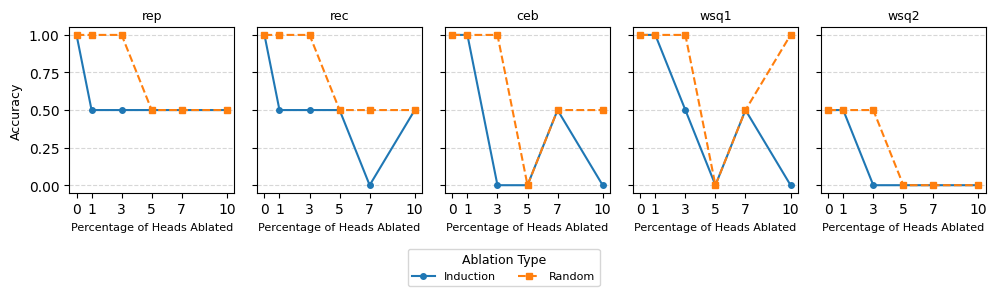

In [11]:
import importlib
importlib.reload(induction_heads)
head_accs = induction_heads.compute_head_ablation_accuracy(hd_result)
induction_heads.plot_head_ablation_results(head_accs)

# Joint ablation experiment

In [16]:
def joint_ab(model, tokenizer, shot=10, seed=42):
    tasks = ['rep', 'rec', 'ceb', 'wsq1','wsq2']
    d = {}
    sortedHeads = induction_heads.compute_prefix_matching_scores(model, tokenizer)
    sortedNeurons = repetition_neurons.find_sorted_neurons(model, tokenizer, base_data=repetition_dataset, seed=seed)

    for task in tqdm(tasks):
        file_data = f"./icl_data/{task}_{shot}shot.jsonl"
        ab_dataset = utils.load_data(file_data)
        ground_truths = [item['ground_truth'] for item in ab_dataset]
        nor_answer = utils.generate_answer(model, tokenizer, ab_dataset, seed)
        
        dual_results = utils.run_dual_ablation_study(
            model=model,
            tokenizer=tokenizer,
            dataset=ab_dataset,          
            sortedNeurons=sortedNeurons,
            id_avg_scores=sortedHeads,   
            percent_list=[1, 3, 5],
            segment_ranges=[(0, 0.2), (0.4, 0.6), (0.8, 1.0)],
            neurons_to_ablate_list=[100, 250],
            shot=shot,
        )
        nor_ =  utils.extract_answers_nor(nor_answer, shots = shot)
        #ab_dual = utils.extract_answers_ab_layer(ab_dual_result, shots=10)
        d[task] = {
            'ground_truths': ground_truths,
            'ab_dual':      dual_results,
            'nor_':          nor_,
        }
    return d

joint_rs = joint_ab(model, tokenizer, shot=10, seed=global_seed)


Generating sequences: 100%|██████████| 5/5 [00:02<00:00,  1.94it/s]


Sorted Repetition Neurons


Compute activation: 100%|██████████| 25/25 [00:20<00:00,  1.24sequence/s]


  0%|          | 0/5 [00:00<?, ?it/s]

Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

...

top Neurons:   0%|          | 0/2 [00:00<?, ?it/s]

random Neurons:   0%|          | 0/2 [00:00<?, ?it/s]

Generate answer by normal mode:   0%|          | 0/2 [00:00<?, ?it/s]

top Neurons:   0%|          | 0/2 [00:00<?, ?it/s]

random Neurons:   0%|          | 0/2 [00:00<?, ?it/s]

In [18]:
def compute_dual_ablation_accuracies_by_class(joint_results):
    """
    From joint_results (with keys 'ground_truths', 'nor_', 'ab_dual'),
    compute for each task:
      - baseline Foo / Bar accuracy
      - for each rep_mode ∈ {'top','random'}, each mask_mode ∈ {'induction','random'},
        each k ∈ neurons_to_ablate_list, each pct ∈ percent_list:
          segment → { 'Foo': acc, 'Bar': acc }
    """
    out = {}
    for task, info in joint_results.items():
        gts  = info['ground_truths']
        n    = len(gts)
        # count examples per class
        foo_idxs = [i for i,gt in enumerate(gts) if gt=='Foo']
        bar_idxs = [i for i,gt in enumerate(gts) if gt=='Bar']

        # baseline
        nor = info['nor_']
        base_foo = sum(1 for i in foo_idxs if nor[i]=='Foo')/len(foo_idxs) if foo_idxs else float('nan')
        base_bar = sum(1 for i in bar_idxs if nor[i]=='Bar')/len(bar_idxs) if bar_idxs else float('nan')

        ab = {}
        for rep_mode, rep_block in info['ab_dual'].items():
            ab[rep_mode] = {}
            for mask_mode, mask_block in rep_block.items():
                ab[rep_mode][mask_mode] = {}
                for k, pct_block in mask_block.items():
                    ab[rep_mode][mask_mode][k] = {}
                    for pct, seg_list in pct_block.items():
                        seg_acc = {}
                        for seg_res in seg_list:
                            seg   = seg_res['segment']
                            preds = seg_res['results']
                            # compute Foo / Bar acc on this segment
                            foo_acc = sum(1 for i in foo_idxs if preds[i]=='Foo')/len(foo_idxs) if foo_idxs else float('nan')
                            bar_acc = sum(1 for i in bar_idxs if preds[i]=='Bar')/len(bar_idxs) if bar_idxs else float('nan')
                            #if foo_acc is n
                            #for i 
                            seg_acc[seg] = {'Foo': foo_acc, 'Bar': bar_acc}
                        ab[rep_mode][mask_mode][k][pct] = seg_acc

        out[task] = {
            'baseline': {'Foo': base_foo, 'Bar': base_bar},
            'ablation': ab
        }

    return out

# Example usage:
dual_accs_class = compute_dual_ablation_accuracies_by_class(joint_rs)
print(dual_accs_class['rep'])

{'baseline': {'Foo': 1.0, 'Bar': 1.0}, 'ablation': {'top': {'induction': {100: {1: {'0->0.2': {'Foo': 1.0, 'Bar': 0.0}, '0.4->0.6': {'Foo': 1.0, 'Bar': 0.0}, '0.8->1.0': {'Foo': 1.0, 'Bar': 1.0}}, 3: {'0->0.2': {'Foo': 0.0, 'Bar': 1.0}, '0.4->0.6': {'Foo': 1.0, 'Bar': 1.0}, '0.8->1.0': {'Foo': 0.0, 'Bar': 1.0}}, 5: {'0->0.2': {'Foo': 0.0, 'Bar': 0.0}, '0.4->0.6': {'Foo': 0.0, 'Bar': 0.0}, '0.8->1.0': {'Foo': 0.0, 'Bar': 1.0}}}, 250: {1: {'0->0.2': {'Foo': 1.0, 'Bar': 0.0}, '0.4->0.6': {'Foo': 1.0, 'Bar': 0.0}, '0.8->1.0': {'Foo': 0.0, 'Bar': 1.0}}, 3: {'0->0.2': {'Foo': 0.0, 'Bar': 1.0}, '0.4->0.6': {'Foo': 1.0, 'Bar': 1.0}, '0.8->1.0': {'Foo': 0.0, 'Bar': 1.0}}, 5: {'0->0.2': {'Foo': 0.0, 'Bar': 0.0}, '0.4->0.6': {'Foo': 0.0, 'Bar': 0.0}, '0.8->1.0': {'Foo': 0.0, 'Bar': 1.0}}}}, 'random': {100: {1: {'0->0.2': {'Foo': 1.0, 'Bar': 1.0}, '0.4->0.6': {'Foo': 1.0, 'Bar': 1.0}, '0.8->1.0': {'Foo': 1.0, 'Bar': 1.0}}, 3: {'0->0.2': {'Foo': 1.0, 'Bar': 1.0}, '0.4->0.6': {'Foo': 1.0, 'Bar': 1.0